# ANN Regression — California Housing

We train a Keras `Sequential` Multi-Layer Perceptron (MLP) to predict median house value from the `fetch_california_housing` dataset (a standard scikit-learn built-in). This exercises forward propagation, backpropagation, the Adam optimizer, and MSE loss as discussed in `notes.md`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print('TF version:', tf.__version__)

I0000 00:00:1787471938.146748   18337 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787471938.147174   18337 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787471938.424394   18337 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787471939.644899   18337 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787471939.645223   18337 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF version: 2.21.0


## Load and split data

The California Housing dataset has 8 numeric features (median income, house age, average rooms, etc.) and a continuous target: median house value (in units of $100,000).

In [2]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
print(X.shape, y.shape)
X.head()

(20640, 8) (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (13209, 8) Val: (3303, 8) Test: (4128, 8)


## Feature scaling

Neural networks train more reliably when input features are on comparable scales, so we standardize each feature to zero mean / unit variance using `StandardScaler` fit only on the training set.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0).round(3), X_train_scaled.std(axis=0).round(3)

(array([-0., -0., -0., -0.,  0.,  0., -0.,  0.]),
 array([1., 1., 1., 1., 1., 1., 1., 1.]))

## Build the MLP

A small `Sequential` network: two hidden `Dense` layers with ReLU activations (He initialization suits ReLU, per `notes.md`), and a single linear output neuron for the regression target.

In [5]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(1, activation='linear'),
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss='mse', metrics=['mae'])
model.summary()

E0000 00:00:1787471940.208745   18337 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787471940.209645   18414 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787471940.330356   18337 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## Train with EarlyStopping

`EarlyStopping` monitors validation loss and restores the best weights, preventing the model from overfitting past the point where validation performance stops improving.

In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=2)

Epoch 1/100


413/413 - 1s - 2ms/step - loss: 1.0851 - mae: 0.6743 - val_loss: 0.6341 - val_mae: 0.5643


Epoch 2/100


413/413 - 0s - 796us/step - loss: 0.7066 - mae: 0.4934 - val_loss: 0.9194 - val_mae: 0.5299


Epoch 3/100


...

413/413 - 0s - 912us/step - loss: 0.2565 - mae: 0.3504 - val_loss: 0.3020 - val_mae: 0.3853


Epoch 46/100


413/413 - 0s - 790us/step - loss: 0.2594 - mae: 0.3507 - val_loss: 0.3200 - val_mae: 0.4062


Epoch 47/100


413/413 - 0s - 789us/step - loss: 0.2882 - mae: 0.3545 - val_loss: 0.3767 - val_mae: 0.4006


## Training curves

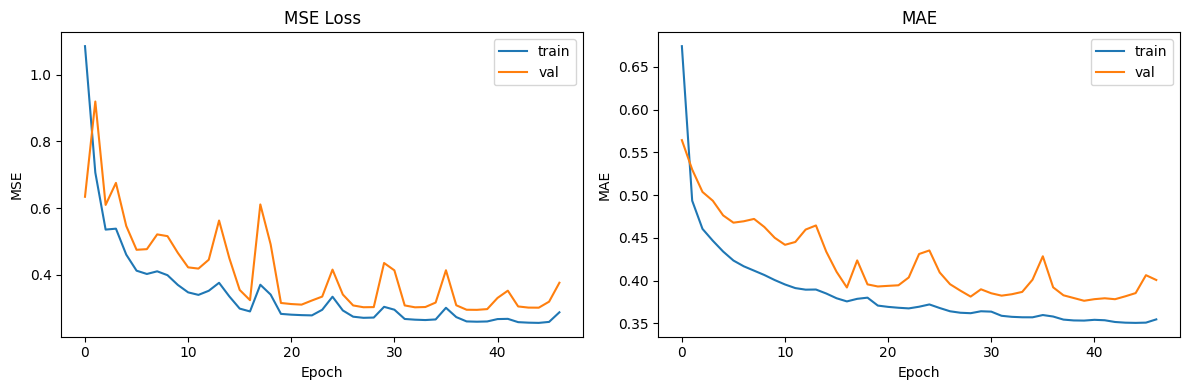

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('MSE Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE'); ax[0].legend()

ax[1].plot(history.history['mae'], label='train')
ax[1].plot(history.history['val_mae'], label='val')
ax[1].set_title('MAE'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('MAE'); ax[1].legend()
plt.tight_layout()
plt.show()

## Evaluate on the test set

In [8]:
y_pred = model.predict(X_test_scaled).flatten()
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'Test MAE:  {mae:.4f}')
print(f'Test RMSE: {rmse:.4f}')

  1/129 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 425us/step


Test MAE:  0.3771
Test RMSE: 0.5404


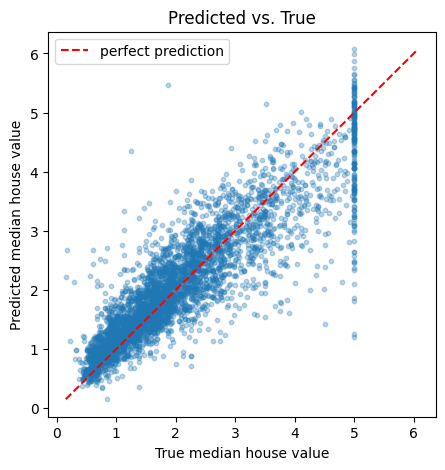

In [9]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='perfect prediction')
plt.xlabel('True median house value')
plt.ylabel('Predicted median house value')
plt.title('Predicted vs. True')
plt.legend()
plt.show()

## Summary

The MLP learns a reasonable regression fit on California Housing with a small 2-hidden-layer network, Adam optimizer, and early stopping — demonstrating the full forward/backward propagation training loop introduced in `notes.md`.